# MentalManip EDA

This notebook explores the Hugging Face `audreyeleven/MentalManip` dataset using the majority-vote config `mentalmanip_maj`. It also shows how the project is split into two stages:

- Stage 1: `Dialogue -> Manipulative`
- Stage 2: `Dialogue -> exact Technique string` on manipulative rows only


In [3]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'notebooks'
PROJECT_ROOT = NOTEBOOK_DIR.parent

sys.path.append(str(PROJECT_ROOT))

RESULTS_DIR = NOTEBOOK_DIR / 'results'
METRICS_DIR = RESULTS_DIR / 'metrics'
PREDICTIONS_DIR = RESULTS_DIR / 'predictions'
FIGURES_DIR = NOTEBOOK_DIR / 'figures'

for path in [METRICS_DIR, PREDICTIONS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data_analysis import data_summary_table, save_stats_json, save_summary_table, save_top_techniques
from src.load_data import (
    DEFAULT_CONFIG,
    build_binary_dataframe,
    build_technique_dataframe,
    load_raw_dataframe,
    print_dataset_stats,
)


## Load MentalManip


In [4]:
raw_df = load_raw_dataframe(config=DEFAULT_CONFIG)
stats = print_dataset_stats(raw_df)

binary_df = build_binary_dataframe(raw_df)
technique_df = build_technique_dataframe(raw_df)

print(f"\nStage 1 rows: {len(binary_df)}")
print(f"Stage 2 rows: {len(technique_df)}")


Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


MentalManip config: mentalmanip_con
Total rows: 2915
Manipulative vs non-manipulative rows: 2016 / 899
Stage-2 technique rows: 1748
Stage-1 class imbalance ratio (majority/minority): 2.242
Stage-2 number of exact technique labels: 135
Stage-2 class size range: 1 to 429

Top 20 technique labels:
Persuasion or Seduction: 429
Intimidation: 193
Shaming or Belittlement: 182
Accusation: 134
Rationalization: 86
Shaming or Belittlement,Accusation: 61
Denial: 45
Evasion: 43
Rationalization,Persuasion or Seduction: 39
Brandishing Anger: 35
Playing Victim Role: 24
Feigning Innocence: 23
Intimidation,Persuasion or Seduction: 23
Shaming or Belittlement,Intimidation: 20
Accusation,Shaming or Belittlement: 20
Shaming or Belittlement,Persuasion or Seduction: 19
Shaming or Belittlement,Brandishing Anger: 16
Persuasion or Seduction,Intimidation: 14
Accusation,Persuasion or Seduction: 14
Playing Victim Role,Accusation: 13


Stage 1 rows: 2915
Stage 2 rows: 1748


## Summary Table


In [5]:
summary_df = data_summary_table(raw_df)
display(summary_df)


,metric,value
0,config,mentalmanip_con
1,total_rows,2915
2,manipulative_rows,2016
3,non_manipulative_rows,899
4,stage2_rows,1748
5,stage2_num_classes,135
6,stage1_imbalance_ratio_majority_to_minority,2.242492
7,smallest_stage2_class_size,1
8,largest_stage2_class_size,429
9,top_technique_count::Persuasion or Seduction,429


## Save Notebook EDA Artifacts


In [6]:
summary_path = save_summary_table(raw_df, output_path=METRICS_DIR / 'mentalmanip_data_summary.csv')
stats_path = save_stats_json(raw_df, output_path=METRICS_DIR / 'mentalmanip_dataset_stats.json')
top_techniques_path = save_top_techniques(raw_df, output_path=METRICS_DIR / 'mentalmanip_top_techniques.csv')

print(summary_path)
print(stats_path)
print(top_techniques_path)


/Users/maycolmeza/Desktop/CODING PROJECTS/485FinalProject/485-Predicting-Manipulation-text/notebooks/results/metrics/mentalmanip_data_summary.csv
/Users/maycolmeza/Desktop/CODING PROJECTS/485FinalProject/485-Predicting-Manipulation-text/notebooks/results/metrics/mentalmanip_dataset_stats.json
/Users/maycolmeza/Desktop/CODING PROJECTS/485FinalProject/485-Predicting-Manipulation-text/notebooks/results/metrics/mentalmanip_top_techniques.csv


## Preview Stage 1 Data


In [7]:
with pd.option_context('display.max_colwidth', 120):
    display(binary_df[['text', 'manipulative', 'technique', 'vulnerability', 'manipulation_type']].head(5))


,text,manipulative,technique,vulnerability,manipulation_type
0,"Person1: Jesus! Listen to this one: ""Do you remember me? Airport shuttle, June 7th. You: striking redhead with yello...",1,,,manipulative
1,Person1: I don't know.\nPerson2: Don't go.\nPerson1: I have to... he's a G-34\nPerson2: You don't have to... I don't...,1,Rationalization,,manipulative
2,"Person1: You're mine, you know. I made you.\nPerson2: I know.\nPerson1: If you went away, what would become of me?\...",1,"Persuasion or Seduction,Accusation",Dependency,manipulative
3,"Person1: All right. Tell 'em to shoot to kill.\nPerson2: What?\nPerson1: Shoot to kill, I said.\nPerson2: I don't kn...",1,"Shaming or Belittlement,Intimidation",,manipulative
4,Person1: You're alive! She didn't kill you!\nPerson2: Who didn't?\nPerson1: That woman who's after me. She hates you...,1,Persuasion or Seduction,,manipulative


## Preview Stage 2 Data


In [8]:
with pd.option_context('display.max_colwidth', 120):
    display(technique_df[['text', 'technique', 'vulnerability', 'manipulation_type']].head(5))


,text,technique,vulnerability,manipulation_type
0,Person1: I don't know.\nPerson2: Don't go.\nPerson1: I have to... he's a G-34\nPerson2: You don't have to... I don't...,Rationalization,,Rationalization
1,"Person1: You're mine, you know. I made you.\nPerson2: I know.\nPerson1: If you went away, what would become of me?\...","Persuasion or Seduction,Accusation",Dependency,"Persuasion or Seduction,Accusation"
2,"Person1: All right. Tell 'em to shoot to kill.\nPerson2: What?\nPerson1: Shoot to kill, I said.\nPerson2: I don't kn...","Shaming or Belittlement,Intimidation",,"Shaming or Belittlement,Intimidation"
3,Person1: You're alive! She didn't kill you!\nPerson2: Who didn't?\nPerson1: That woman who's after me. She hates you...,Persuasion or Seduction,,Persuasion or Seduction
4,Person1: I like you so much. I think you're beautiful. I think if we were together you would love it. You wouldn't b...,Persuasion or Seduction,,Persuasion or Seduction


## Top 20 Technique Labels


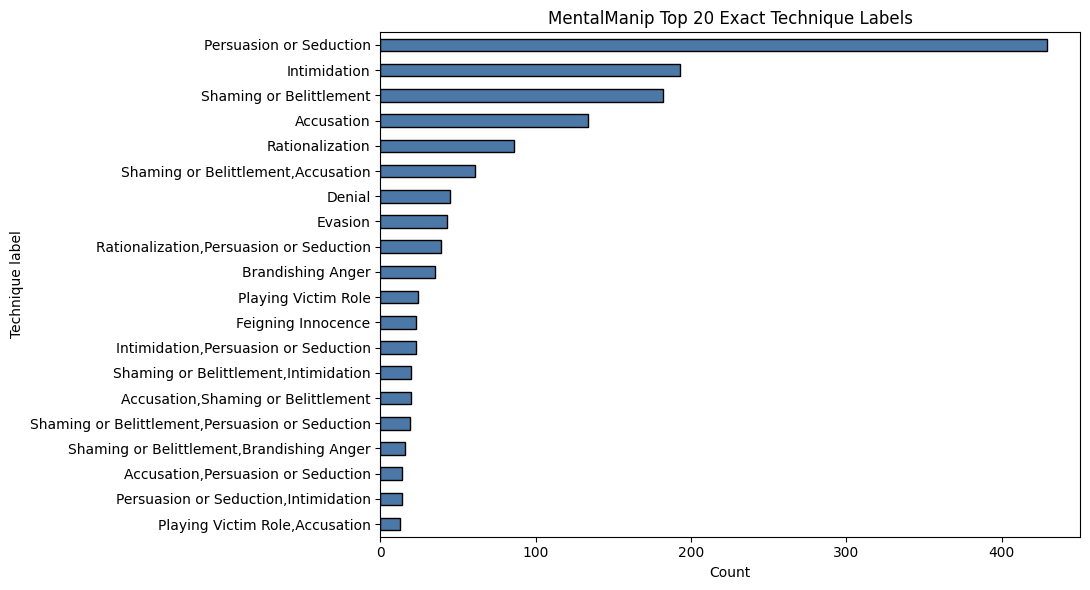

Saved figure to: /Users/maycolmeza/Desktop/CODING PROJECTS/485FinalProject/485-Predicting-Manipulation-text/notebooks/figures/mentalmanip_top_20_techniques.png


In [9]:
top_20 = technique_df['manipulation_type'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(11, 6))
top_20.sort_values().plot(kind='barh', ax=ax, color='#4C78A8', edgecolor='black')
ax.set_title('MentalManip Top 20 Exact Technique Labels')
ax.set_xlabel('Count')
ax.set_ylabel('Technique label')
fig.tight_layout()
figure_path = FIGURES_DIR / 'mentalmanip_top_20_techniques.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved figure to: {figure_path}')
